# Building an Assistant

Sub-goals, controlability, external tools, and parallelisation

| Date | User | Change Type | Remarks |  
| ---- | ---- | ----------- | ------- |
| 26/05/26   | Martin | CREATE   | Notebook for Module 4 of Langgraph tutorial. Parallelisation | 
| 28/05/26   | Martin | UPDATE   | Sub-graphs and Map-reduce | 
| 04/06/26   | Martin | UPDATE   | Started on research agent | 

# Content

* [Parallelisation](#parallelisation)
* [Sub-Graphs](#sub-graphs)
* [Map-Reduce](#map-reduce)

# Parallelisation

Running multiple nodes that update the state at the same time. _Fan-in-fan-out_ is one of the ways a graph can be contructed to run in parallel i.e at least 2 nodes running at the same time.

__BUT__ because the state is always overridden, a __reducer__ is required to run parallel nodes

- All steps within a parallel path will wait for each other to complete before proceeding on to the next step

In [ ]:
import os
import operator
from dotenv import load_dotenv

from typing import TypedDict, Annotated
from langgraph.graph import StateGraph
from langgraph.constants import START, END
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_community.document_loaders import WikipediaLoader
from langchain_tavily import TavilySearch

from IPython.display import Image, display

load_dotenv()
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv("GROQ_API_KEY", "")
)

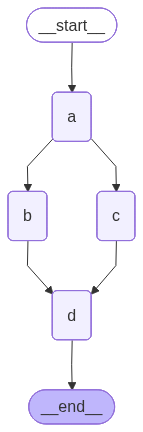

In [5]:
class State(TypedDict):
    state: Annotated[list, operator.add]

class ReturnNodeValue:
    def __init__(self, node_secret: str):
        self._value = node_secret

    def __call__(self, state: State):
        print(f"Adding {self._value} to {state['state']}")
        return {"state": [self._value]}

builder = StateGraph(State)
builder.add_node("a", ReturnNodeValue("I'm A."))
builder.add_node("b", ReturnNodeValue("I'm B."))
builder.add_node("c", ReturnNodeValue("I'm C."))
builder.add_node("d", ReturnNodeValue("I'm D."))

builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("a", "c")
builder.add_edge("b", "d")
builder.add_edge("c", "d")
builder.add_edge("d", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

__🧑‍🏫 LESSON:__ Here because nodes "b" and "c" need to simultaneously update the state (which by default will override) we use the `operator.add` with a custom State to ensure values get appended

In [4]:
graph.invoke({"state": []})

Adding I'm A. to []
Adding I'm B. to ["I'm A."]
Adding I'm C. to ["I'm A."]
Adding I'm D. to ["I'm A.", "I'm B.", "I'm C."]


{'state': ["I'm A.", "I'm B.", "I'm C.", "I'm D."]}

## Setting the order of state updates

Use a __custom reducer__ to customise the order of nodes which are run within the parallised loop.

🥬 e.g. Below shows a reducer that runs the nodes based on their sorted name order

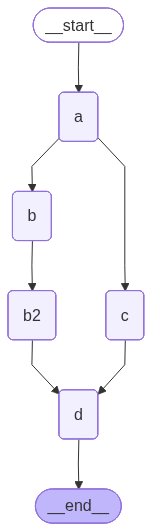

In [10]:
def sorting_reducer(left: list, right: list) -> list:
    """ Combines and sorts the values in a list"""
    return sorted(left + right, reverse=False)

class State(TypedDict):
    # sorting_reducer will sort the values in state
    state: Annotated[list, sorting_reducer]

class ReturnNodeValue:
    def __init__(self, node_secret: str):
        self._value = node_secret

    def __call__(self, state: State):
        print(f"Adding {self._value} to {state['state']}")
        return {"state": [self._value]}


# Add nodes
builder = StateGraph(State)

# Initialize each node with node_secret 
builder.add_node("a", ReturnNodeValue("I'm A"))
builder.add_node("b", ReturnNodeValue("I'm B"))
builder.add_node("b2", ReturnNodeValue("I'm B2"))
builder.add_node("c", ReturnNodeValue("I'm C"))
builder.add_node("d", ReturnNodeValue("I'm D"))

# Flow
builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("a", "c")
builder.add_edge("b", "b2")
builder.add_edge(["b2", "c"], "d")
builder.add_edge("d", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
graph.invoke({"state": []})

Adding I'm A to []
Adding I'm B to ["I'm A"]
Adding I'm C to ["I'm A"]
Adding I'm B2 to ["I'm A", "I'm B", "I'm C"]
Adding I'm D to ["I'm A", "I'm B", "I'm B2", "I'm C"]


{'state': ["I'm A", "I'm B", "I'm B2", "I'm C", "I'm D"]}

## Working with LLMs

Combining a parallel routing with LLMs

In [13]:
class State(TypedDict):
    question: str
    answer: str
    context: Annotated[list, operator.add]

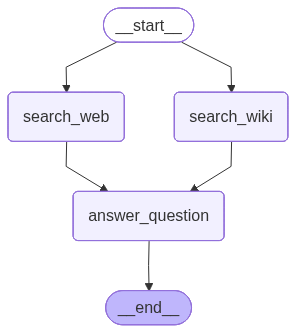

In [14]:
def search_web(state):
    """Retrieve docs from web search"""
    # Search
    tavily_search = TavilySearch(max_results=3)
    data = tavily_search.invoke({"query": state['question']})
    search_docs = data.get("results", data)

    # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document href="{doc["url"]}">\n{doc["content"]}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]}

def search_wikipedia(state):
    """Retreive documents from wikipedia"""
    search_docs = WikipediaLoader(query=state['question'], load_max_docs=2).load()

    # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document source="{doc.metadata["source"]}" page="{doc.metadata.get("page", "")}">\n{doc.page_content}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]}

def generate_answer(state):
    """Node to answer questions"""
    # Get state
    question = state['question']
    context = state['context']

    # Format
    query = f"Answer the question {question} using this context: {context}"

    # Answer
    answer = llm.invoke(
        [SystemMessage(content=query)],
        [HumanMessage(content="Answer the question.")]
    )

    return {"answer": answer}

builder = StateGraph(State)
builder.add_node("search_web", search_web)
builder.add_node("search_wiki", search_wikipedia)
builder.add_node("answer_question", generate_answer)

builder.add_edge(START, "search_wiki")
builder.add_edge(START, "search_web")
builder.add_edge("search_wiki", "answer_question")
builder.add_edge("search_web", "answer_question")
builder.add_edge("answer_question", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
result = graph.invoke({"question": "How were Nvidia's Q2 2025 earnings"})
result['answer'].content

---

# Sub-graphs

Sub-graphs allow you to create and manage different states in different parts of the graph.

Communication between graphs is done via __overlapping keys__

- Sub-graphs can access key from the parent graph if they are the same

🥬 e.g. Logs with different tasks

- System accepts logs
- 1 task summarises the logs, 1 task finds failure nodes
- Perform both operations in different subgraphs

![subgraphs](./assets/subgraph.png)

In [ ]:
from operator import add
from typing import TypedDict, List, Optional, Annotated

from langgraph.graph import StateGraph
from langgraph.constants import START, END

In [16]:
# Define the entire log structure
class Log(TypedDict):
    id: str
    question: str
    docs: Optional[List]
    answer: str
    grade: Optional[int]
    grader: Optional[str]
    feedback: Optional[str]

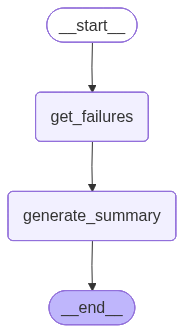

In [17]:
# Failure analysis sub-graph
class FailureAnalysisState(TypedDict):
    cleaned_logs: List[Log]
    failures: List[Log]
    fa_summary: str
    processed_logs: List[str]

# Define a separate output state, so that when the subgraph returns results back to
# main graph, there won't be a collision in the results returned
class FailureAnalysisOutputState(TypedDict):
    fa_summary: str
    processed_logs: List[str]

def get_failures(state):
    """Get logs that contain failures"""
    failures = [log for log in state['cleaned_logs'] if "grade" in log]
    return {"failures": failures}

def generate_summary(state):
    """Generate a summary of the failures"""
    failures = state['failures']
    fa_summary = "Poor quality retrieval of Chroma documentation."
    return {
        "fa_summary": fa_summary,
        "processed_logs": [
            f"failure-analysis-on-log-{failure['id']}" for failure in failures
        ]
    }

fa_builder = StateGraph(
    state_schema=FailureAnalysisState,
    output_schema=FailureAnalysisOutputState
)
fa_builder.add_node("get_failures", get_failures)
fa_builder.add_node("generate_summary", generate_summary)

fa_builder.add_edge(START, "get_failures")
fa_builder.add_edge("get_failures", "generate_summary")
fa_builder.add_edge("generate_summary", END)

graph = fa_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

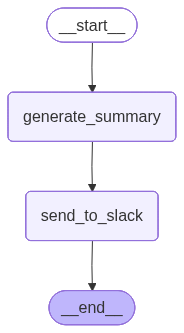

In [18]:
# Summarisation sub-graph
class QuestionSummarisationState(TypedDict):
    cleaned_logs: List[Log]
    qs_summary: str
    report: str
    processed_logs: List[str]

class QuestionSummarisationOutputState(TypedDict):
    report: str
    processed_logs: List[str]

def generate_summary(state):
    cleaned_logs = state["cleaned_logs"]
    summary = "Questions focused on usage of ChatOllama and Chroma vector store."
    return {
        "qs_summary": summary,
        "processed_logs": [f"summary-on-log-{log['id']}" for log in cleaned_logs]
    }

def send_to_slack(state):
    qs_summary = state['qs_summary']
    report = f"Some report generated from the summary: {qs_summary}"
    return {"report": report}

qs_builder = StateGraph(
    state_schema=QuestionSummarisationState,
    output_schema=QuestionSummarisationOutputState
)
qs_builder.add_node("generate_summary", generate_summary)
qs_builder.add_node("send_to_slack", send_to_slack)

qs_builder.add_edge(START, "generate_summary")
qs_builder.add_edge("generate_summary", "send_to_slack")
qs_builder.add_edge("send_to_slack", END)

graph = qs_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

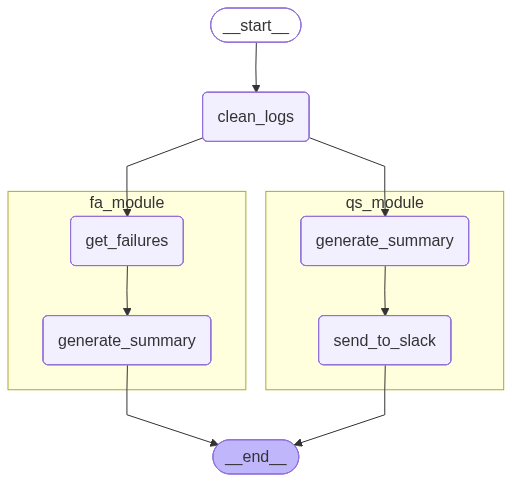

In [21]:
# Entry graph - Main graph loop
class EntryGraphState(TypedDict):
    raw_logs: List[Log]
    cleaned_logs: List[Log]
    fa_summary: str                            # Used only by FA sub-graph
    report: str                                # Used only by QS sub-graph
    processed_logs: Annotated[List[int], add]  # Used and updated by both graphs

def clean_logs(state):
    raw_logs = state["raw_logs"]
    cleaned_logs = raw_logs  # Some cleaning can be done here
    return {"cleaned_logs": raw_logs}

entry_builder = StateGraph(EntryGraphState)
entry_builder.add_node("clean_logs", clean_logs)
entry_builder.add_node("qs_module", qs_builder.compile())
entry_builder.add_node("fa_module", fa_builder.compile())

entry_builder.add_edge(START, "clean_logs")
entry_builder.add_edge("clean_logs", "qs_module")
entry_builder.add_edge("clean_logs", "fa_module")
entry_builder.add_edge("fa_module", END)
entry_builder.add_edge("qs_module", END)

graph = entry_builder.compile()
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [22]:
question_answer = Log(
    id="1",
    question="How can I import ChatOllama?",
    answer="To import ChatOllama, use: 'from langchain_community.chat_models import ChatOllama.'",
)

question_answer_feedback = Log(
    id="2",
    question="How can I use Chroma vector store?",
    answer="To use Chroma, define: rag_chain = create_retrieval_chain(retriever, question_answer_chain).",
    grade=0,
    grader="Document Relevance Recall",
    feedback="The retrieved documents discuss vector stores in general, but not Chroma specifically",
)

raw_logs = [question_answer,question_answer_feedback]
graph.invoke({"raw_logs": raw_logs})

{'raw_logs': [{'id': '1',
   'question': 'How can I import ChatOllama?',
   'answer': "To import ChatOllama, use: 'from langchain_community.chat_models import ChatOllama.'"},
  {'id': '2',
   'question': 'How can I use Chroma vector store?',
   'answer': 'To use Chroma, define: rag_chain = create_retrieval_chain(retriever, question_answer_chain).',
   'grade': 0,
   'grader': 'Document Relevance Recall',
   'feedback': 'The retrieved documents discuss vector stores in general, but not Chroma specifically'}],
 'cleaned_logs': [{'id': '1',
   'question': 'How can I import ChatOllama?',
   'answer': "To import ChatOllama, use: 'from langchain_community.chat_models import ChatOllama.'"},
  {'id': '2',
   'question': 'How can I use Chroma vector store?',
   'answer': 'To use Chroma, define: rag_chain = create_retrieval_chain(retriever, question_answer_chain).',
   'grade': 0,
   'grader': 'Document Relevance Recall',
   'feedback': 'The retrieved documents discuss vector stores in general, 

---

# Map-Reduce

The map-reduce paradigm allows us to spawn any number of replicated nodes to perform tasks in parallel for different instances, then combine them back into a single output.

🥬 e.g. Build a joke creator based on a topic and selects the best one

In [1]:
import os
import operator
from dotenv import load_dotenv
from pydantic import BaseModel

from typing import TypedDict, Annotated
from langgraph.graph import StateGraph
from langgraph.constants import START, END
from langgraph.types import Send
from langchain_groq import ChatGroq

from IPython.display import Image

load_dotenv()
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv("GROQ_API_KEY", "")
)

In [2]:
subject_prompt = "Create a list of 3 sub-topics that are related to the overall " \
    "topic: {topic}."
joke_prompt = "Generate a joke about: {subject}"
best_joke_prompt = "Based on the jokes below on {topic}. Select the best one, and" \
    "return the ID of the selected, starting 0 as the ID for the first joke. Jokes: " \
    "\n\n {jokes}"

In [3]:
# Define the States
class Subject(BaseModel):
    subjects: list[str]

class BestJoke(BaseModel):
    id: int

class OverallState(TypedDict):
    topic: str
    subjects: list[str]
    jokes: Annotated[list[str], operator.add]
    best_selected_joke: str

In [4]:
def generate_topics(state: OverallState):
    """Generate a set of subjects based on the topic given"""
    prompt = subject_prompt.format(topic=state['topic'])
    subjects = llm.with_structured_output(Subject).invoke(prompt)
    return {"subjects": subjects.subjects}

def continue_to_jokes(state: OverallState):
    """For every subject created, send it to a node to create a joke"""
    return [Send("generate_joke", {"subject": s}) for s in state['subjects']]

In [5]:
class JokeState(BaseModel):
    subject: str

class Joke(BaseModel):
    joke: str

def generate_joke(state: JokeState):
    """Generate a joke based on the topic"""
    prompt = joke_prompt.format(subject=state['subject'])
    joke = llm.with_structured_output(Joke).invoke(prompt)
    return {"jokes": [joke.joke]}

In [6]:
def get_best_joke(state: OverallState):
    jokes = "\n\n".join(state['jokes'])
    prompt = best_joke_prompt.format(
        topic=state['topic'],
        jokes=jokes
    )
    best = llm.with_structured_output(BestJoke).invoke(prompt)
    return {"best_selected_joke": state['jokes'][best.id]}

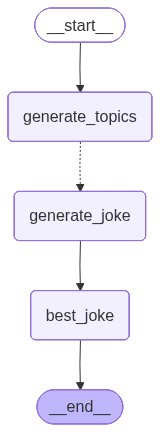

In [7]:
graph = StateGraph(OverallState)
graph.add_node("generate_topics", generate_topics)
graph.add_node("generate_joke", generate_joke)
graph.add_node("best_joke", get_best_joke)

graph.add_edge(START, "generate_topics")
graph.add_conditional_edges("generate_topics", continue_to_jokes, ["generate_joke"])
graph.add_edge("generate_joke", "best_joke")
graph.add_edge("best_joke", END)

app = graph.compile()
Image(app.get_graph().draw_mermaid_png())

In [8]:
for s in app.stream({"topic": "board games"}):
    print(s)

{'generate_topics': {'subjects': ['Types of Board Games', 'Board Game Mechanics', 'History of Board Games']}}
{'generate_joke': {'jokes': ['Why did the board game pieces go to therapy? Because they were feeling a little boxed in!']}}
{'generate_joke': {'jokes': ['Why did the board game go to therapy? It had a lot of history to work through!']}}
{'generate_joke': {'jokes': ['Why did the game designer break up with his girlfriend? He needed space, but she was always rolling a 7.']}}
{'best_joke': {'best_selected_joke': 'Why did the board game pieces go to therapy? Because they were feeling a little boxed in!'}}


---

# Research Assistant

Multi-agent research automation system. Raw LLM outputs are poorly suited for real-world workflows or challenging decisions. 

🎯 GOAL: Build a lightweight, multi-agent system around LLMs that optimises and customises the research process

<u>Process</u>

1. __Source Selection__: User chooses any set of input sources for the research
2. __Planning__: Based on a chosen topic, spin up multiple agents each focusing on a sub-topic. Human-in-the-loop to refine sub-topics before research begins
3. __LLM Utilisation__: "Analyst" (Agent) will continually ask questions and answer them and produce the research output
4. __Research Process__: Experts will gather information in parallel and map-reduce will compile them together
5. __Output Format__: Gathered insights will be synthesized into a final report. Custom report structure

In [9]:
import os

from typing import TypedDict, List
from pydantic import BaseModel, Field
from dotenv import load_dotenv
from IPython.display import Image, display

from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.constants import START, END
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph
from langgraph.checkpoint.memory import MemorySaver

load_dotenv()
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv("GROQ_API_KEY", "")
)

In [5]:
# Define states
class Analyst(BaseModel):
    affliation: str = Field(description="Primary affilisation of the analyst")
    name: str = Field(description="Name of the analyst")
    role: str = Field(description="Role of the analyst in the context of the topic")
    description: str = Field(
        description="Description of the analyst focus, concerns and motives"
    )

    @property
    def persona(self) -> str:
        return f"Name: {self.name}\nRole: {self.role}\n Affiliation: {self.affliation}" \
               f"\nDescription: {self.description}\n"

class Perspectives(BaseModel):
    analysts: List[Analyst] = Field(
        description="List of analysts with roles and affiliations"
    )

class GenerateAnalystsState(TypedDict):
    topic: str                  # Research topic
    max_analysts: int           # Number of analysts
    human_analyst_feedback: str # Human feedback
    analysts: List[Analyst]     # Analysts asking questions

In [6]:
analyst_instructions = """You are tasked with creating a set of AI analyst personas.
Follow these instructions carefully:

1. First, review the research topic:
{topic}

2. Examine any editorial feedback that has been optionally provided to guide creation of
the analysts:

{human_analyst_feedback}

3. Determine the most interesting themes based upon documents and / or feedback above.

4. Pick the top {max_analysts} themes?

5. Assign one analyst to each theme?"""

def create_analysts(state: GenerateAnalystsState):
    """Create Analysts"""
    topic = state['topic']
    max_analysts = state['max_analysts']
    human_analyst_feedback = state.get('human_analyst_feedback', '')

    # Enforce structured output
    structured_llm = llm.with_structured_output(Perspectives)

    system_message = analyst_instructions.format(
        topic=topic,
        human_analyst_feedback=human_analyst_feedback,
        max_analysts=max_analysts
    )

    # Invoke the LLM
    analysts = structured_llm.invoke(
        [SystemMessage(content=system_message)] +
        [HumanMessage(content="Generate a set of analysts")]
    )

    return {"analysts": analysts.analysts}


def human_feedback(state: GenerateAnalystsState):
    """Np-op node that should be interrupted on"""


def should_continue(state: GenerateAnalystsState):
    human_analyst_feedback = state.get('human_analyst_feedback', None)
    if human_analyst_feedback:
        return "create_analysts"

    return END

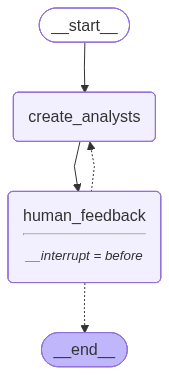

In [10]:
builder = StateGraph(GenerateAnalystsState)
builder.add_node("create_analysts", create_analysts)
builder.add_node("human_feedback", human_feedback)

builder.add_edge(START, "create_analysts")
builder.add_edge("create_analysts", "human_feedback")
builder.add_conditional_edges(
    "human_feedback",
    should_continue,
    ["create_analysts", END]
)

memory = MemorySaver()
graph = builder.compile(
    checkpointer=memory,
    interrupt_before=['human_feedback']
)

display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [ ]:
%load_ext watermark
%watermark